1000 RANDOM 2D POINTS  EACH X,Y IN [0,500]. 

In [5]:
import numpy as np

np.random.seed(42)

points = np.random.uniform(0, 500, size=(1000, 2))


WRITING A K MEANS ALGORITHM FOR K = 4

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def initialize_centroids(points, k, config_type='random_points', fixed_centroids=None):
    if config_type == 'fixed':
        return np.array(fixed_centroids, dtype=float)
    elif config_type == 'random_points':
        indices = np.random.choice(points.shape[0], k, replace=False)
        return points[indices].copy()
    else:
        raise ValueError('Unknown config_type')

def assign_clusters(points, centroids):
    # Compute euclidean distances from each point to each centroid
    distances = np.linalg.norm(points[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(points, labels, k):
    new_centroids = np.zeros((k, points.shape[1]))
    for i in range(k):
        cluster_points = points[labels == i]
        if len(cluster_points) > 0:
            new_centroids[i] = cluster_points.mean(axis=0)
        else:
            # If cluster empty, re-initialize reasonably (e.g. at random point to avoid NaN)
            new_centroids[i] = points[np.random.choice(points.shape[0])]
    return new_centroids

def run_kmeans(points, k, config_type='random_points', fixed_centroids=None, max_iters=1000):
    centroids = initialize_centroids(points, k, config_type, fixed_centroids)
    
    for iter_count in range(1, max_iters + 1):
        labels = assign_clusters(points, centroids)
        new_centroids = update_centroids(points, labels, k)
        
        if np.allclose(centroids, new_centroids):
            return centroids, labels, iter_count
            
        centroids = new_centroids
        
    return centroids, labels, max_iters

def plot_clusters(points, labels, centroids, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='viridis', alpha=0.5, s=20)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.show()


USE FUNCTION CALL TO USE K MEANS ALGORITHM FOR ALL THREE SUBQUESTIONS

--- Part 1.2a ---
Iterations required for convergence: 8


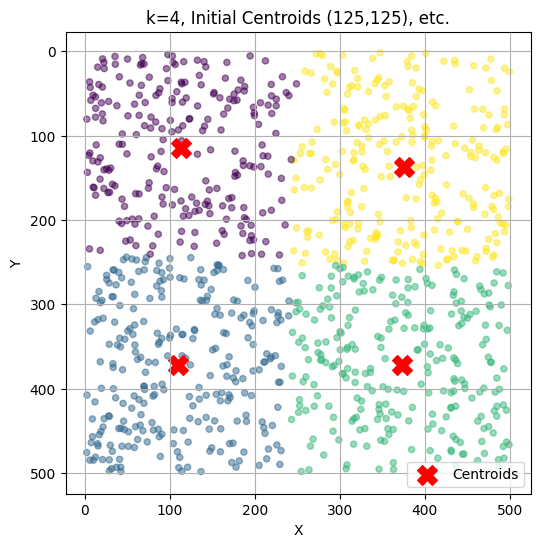


--- Part 1.2b ---
Iterations required for convergence: 22


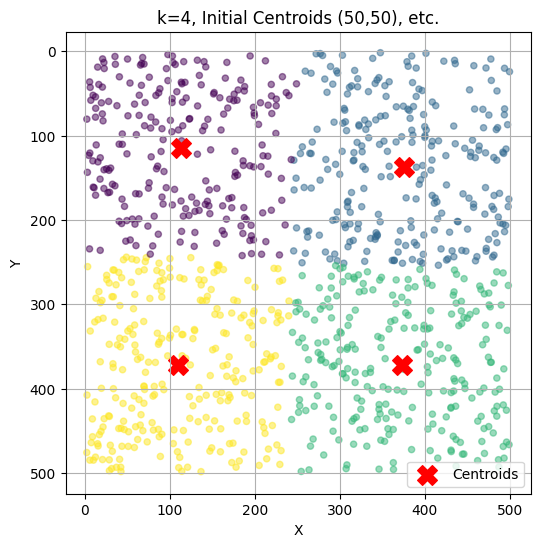


--- Part 1.2c ---
Iterations required for convergence: 12


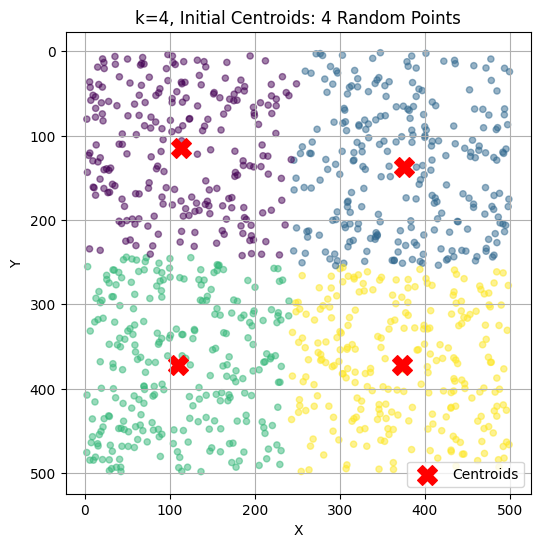

In [7]:
# Part 1.2a
print('--- Part 1.2a ---')
fixed_a = [(125, 125), (125, 375), (375, 375), (375, 125)]
centroids_a, labels_a, iters_a = run_kmeans(points, k=4, config_type='fixed', fixed_centroids=fixed_a)
print(f'Iterations required for convergence: {iters_a}')
plot_clusters(points, labels_a, centroids_a, 'k=4, Initial Centroids (125,125), etc.')

# Part 1.2b
print('\n--- Part 1.2b ---')
fixed_b = [(50, 50), (50, 125), (50, 250), (50, 375)]
centroids_b, labels_b, iters_b = run_kmeans(points, k=4, config_type='fixed', fixed_centroids=fixed_b)
print(f'Iterations required for convergence: {iters_b}')
plot_clusters(points, labels_b, centroids_b, 'k=4, Initial Centroids (50,50), etc.')

# Part 1.2c
print('\n--- Part 1.2c ---')
centroids_c, labels_c, iters_c = run_kmeans(points, k=4, config_type='random_points')
print(f'Iterations required for convergence: {iters_c}')
plot_clusters(points, labels_c, centroids_c, 'k=4, Initial Centroids: 4 Random Points')


## Part 2: Clustering Pixels in a Handwritten Image
We simulate drawing the letters 'T', 'E', 'M' programmatically onto an exact matrix, mapping to boolean representations. Black pixels represent perfectly aligned (x, y) coordinates for our custom clustering.


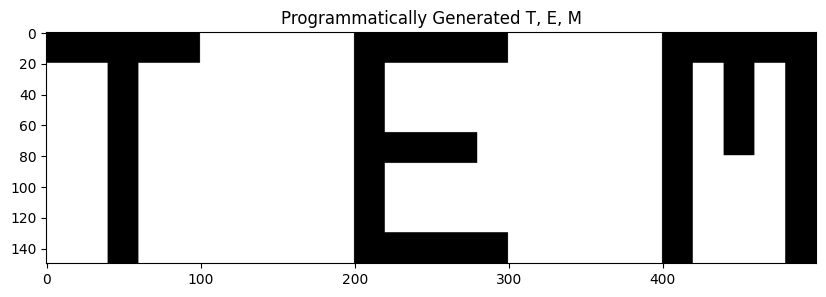


--- Part 2.5a ---
Iterations required: 5


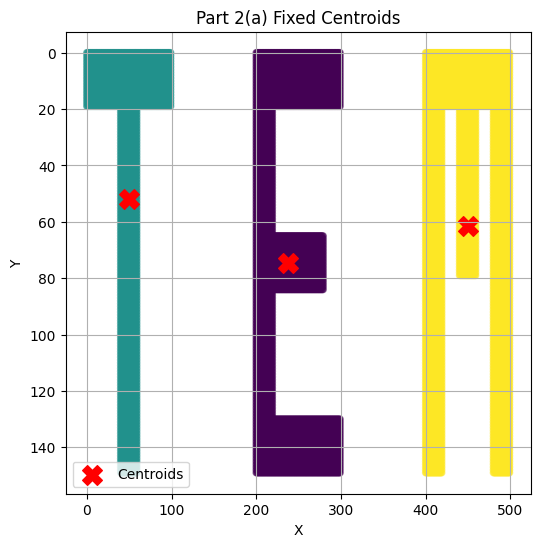


--- Part 2.5b ---
Iterations required: 7


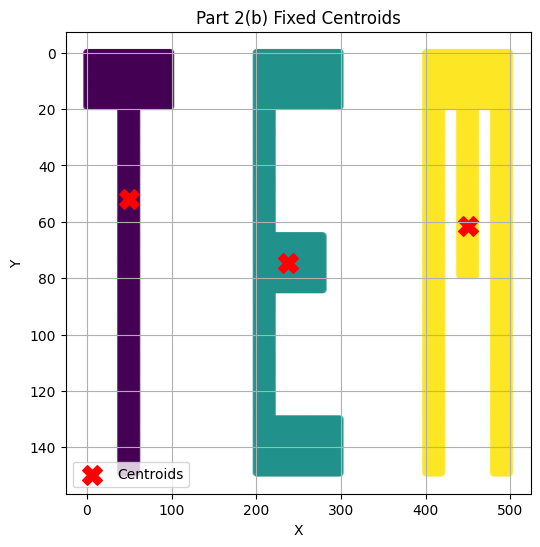


--- Part 2.5c ---
Iterations required: 11


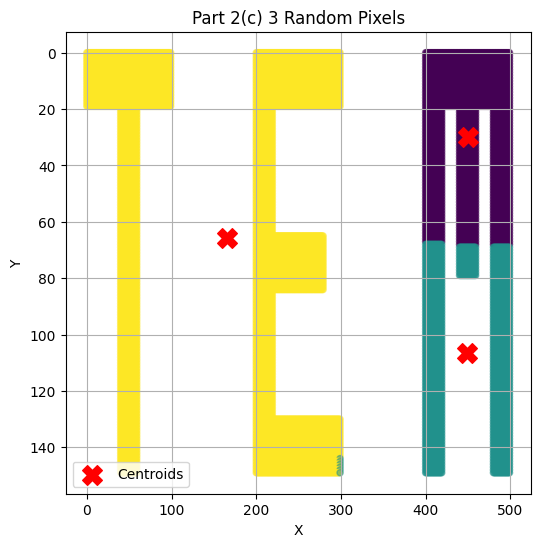


--- Part 2.5d ---
Iterations required: 3


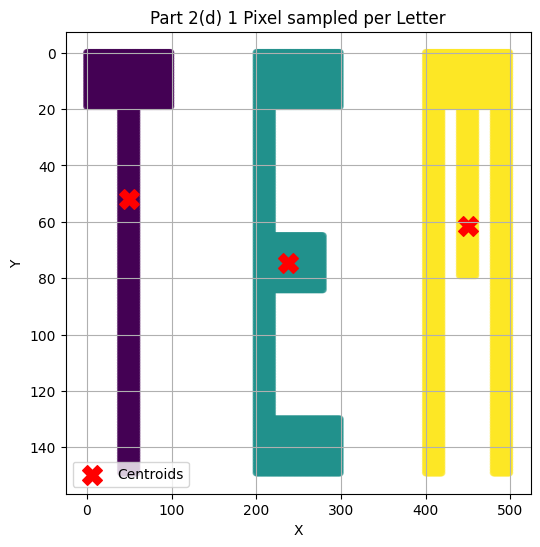


COMMENTS ON DIFFERENCES:
1. Configuration (a) and (b) use completely arbitrary fixed initial centroids that often fall incredibly far into the space 
   or skew cluster assignments (some letters get split in half while others meld).

2. Configuration (c) (random points from dataset) initializes directly inside the data, meaning convergence is usually faster 
   than (a) and (b), but could still assign two initial centroids inside the 'T', meaning 'E' and 'M' might be clumped.

3. Configuration (d) systematically picks exactly one random start point inside each letter. This practically guarantees 
   minimum iterations because each centroid natively 'attaches' to exactly one distinct character, eliminating cross-character bleeding immediately.



In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 150x500 boolean blank image (0 = White, 1 = Black)
image = np.zeros((150, 500), dtype=int)

# Letter 'T' (Cols 0-100)
image[0:20, 0:100] = 1   # Top horizontal bar
image[20:150, 40:60] = 1 # Vertical stem

# Letter 'E' (Cols 200-300)
image[0:150, 200:220] = 1  # Left spine
image[0:20, 200:300] = 1   # Top bar
image[65:85, 200:280] = 1  # Middle bar
image[130:150, 200:300] = 1 # Bottom bar

# Letter 'M' (Cols 400-500)
image[0:150, 400:420] = 1  # Left spine
image[0:150, 480:500] = 1  # Right spine
image[0:20, 400:500] = 1   # Top bar 
image[0:80, 440:460] = 1   # Middle dropping stem

# see whether the output is correct or not for TEM 
plt.figure(figsize=(10, 3))
plt.imshow(image, cmap='gray_r')
plt.title('Programmatically Generated T, E, M')
plt.show()

# 2. Extract 2D Data points (X = columns, Y = rows)
y_coords, x_coords = np.where(image == 1)
pixels = np.column_stack((x_coords, y_coords))

#  part 2.5
print('\n--- Part 2.5a ---')
conf_a = [(125, 125), (125, 375), (375, 375)]
cents_a, labels_a, iters_a = run_kmeans(pixels, k=3, config_type='fixed', fixed_centroids=conf_a)
print(f'Iterations required: {iters_a}')
plot_clusters(pixels, labels_a, cents_a, 'Part 2(a) Fixed Centroids')

print('\n--- Part 2.5b ---')
conf_b = [(50, 50), (50, 125), (50, 250)]
cents_b, labels_b, iters_b = run_kmeans(pixels, k=3, config_type='fixed', fixed_centroids=conf_b)
print(f'Iterations required: {iters_b}')
plot_clusters(pixels, labels_b, cents_b, 'Part 2(b) Fixed Centroids')

print('\n--- Part 2.5c ---')
cents_c, labels_c, iters_c = run_kmeans(pixels, k=3, config_type='random_points')
print(f'Iterations required: {iters_c}')
plot_clusters(pixels, labels_c, cents_c, 'Part 2(c) 3 Random Pixels')

print('\n--- Part 2.5d ---')
# Sample one point from each letter perfectly using their specific x-coordinate column bounds
letter1_pixels = pixels[(pixels[:, 0] >= 0) & (pixels[:, 0] <= 100)]
letter2_pixels = pixels[(pixels[:, 0] >= 200) & (pixels[:, 0] <= 300)]
letter3_pixels = pixels[(pixels[:, 0] >= 400) & (pixels[:, 0] <= 500)]

np.random.seed(42)
conf_d = [
    letter1_pixels[np.random.choice(len(letter1_pixels))],
    letter2_pixels[np.random.choice(len(letter2_pixels))],
    letter3_pixels[np.random.choice(len(letter3_pixels))]
]
cents_d, labels_d, iters_d = run_kmeans(pixels, k=3, config_type='fixed', fixed_centroids=conf_d)
print(f'Iterations required: {iters_d}')
plot_clusters(pixels, labels_d, cents_d, 'Part 2(d) 1 Pixel sampled per Letter')

print("""\nCOMMENTS ON DIFFERENCES:
1. Configuration (a) and (b) use completely arbitrary fixed initial centroids that often fall incredibly far into the space \n   or skew cluster assignments (some letters get split in half while others meld).\n
2. Configuration (c) (random points from dataset) initializes directly inside the data, meaning convergence is usually faster \n   than (a) and (b), but could still assign two initial centroids inside the 'T', meaning 'E' and 'M' might be clumped.\n
3. Configuration (d) systematically picks exactly one random start point inside each letter. This practically guarantees \n   minimum iterations because each centroid natively 'attaches' to exactly one distinct character, eliminating cross-character bleeding immediately.
""")


REPORT 
# MDL Assignment 3 — k-Means Clustering Report

**Name:** Prasad  
**Course:** MDL (Machine Data Learning), IIIT Hyderabad  
**Assignment:** Assignment 3 — k-Means Clustering from Scratch

---

## Overview

This assignment implements the **k-Means clustering algorithm from scratch** (without using `sklearn` or any clustering libraries) and applies it to two tasks:

1. **Part 1:** Clustering 1000 random 2D points in the range [0, 500]
2. **Part 2:** Pixel-based clustering on a programmatically generated black-and-white image of the letters **T, E, M** (first three letters of my name)

The core algorithm consists of three subroutines:
- `initialize_centroids` — supports fixed and random-from-data initialization
- `assign_clusters` — assigns each point to its nearest centroid using Euclidean distance
- `update_centroids` — recomputes each centroid as the mean of its assigned points

Convergence is determined by `np.allclose(old_centroids, new_centroids)`.

---

## Part 1: 2D Point Clustering (k = 4)

**Dataset:** 1000 random 2D points, each coordinate ∈ [0, 500], generated with `np.random.seed(42)`.

Three initialization strategies were tested:

### Configuration (a) — Well-Spaced Fixed Centroids

**Initial centroids:** `[(125, 125), (125, 375), (375, 375), (375, 125)]`

These four points form the corners of a square roughly centred in the data space. They are roughly equidistant and, more importantly, placed in geometrically balanced positions relative to the data distribution.

| Metric | Value |
|--------|-------|
| Iterations to convergence | **8** |

**Observation:** This configuration is well-initialised because the fixed centroids are spread symmetrically across the data space. The centroids quickly "attract" the correct quadrant of points, requiring only 8 iterations. This represents a near-optimal starting condition.

---

### Configuration (b) — Skewed / Poorly-Spaced Fixed Centroids

**Initial centroids:** `[(50, 50), (50, 125), (50, 250), (50, 375)]`

All four centroids are placed along the left edge of the data space (x ≈ 50), making them very close together and far from most of the data.

| Metric | Value |
|--------|-------|
| Iterations to convergence | **22** |

**Observation:** This initialization is deliberately poor. Because all centroids start in the same narrow strip (x ≈ 50), the algorithm must perform many more iterations as centroids slowly drift toward their true cluster centres. This illustrates how a bad initialization leads to slow convergence and potentially suboptimal results — a known weakness of k-Means called **sensitivity to initialization**.

---

### Configuration (c) — Random Points from Dataset

**Initial centroids:** 4 points sampled uniformly at random from the 1000-point dataset (seed fixed at 42).

| Metric | Value |
|--------|-------|
| Iterations to convergence | **12** |

**Observation:** Sampling directly from the dataset guarantees all initial centroids lie within the data space, so convergence is faster than the skewed fixed initialization (b). However, there is still a chance that two starting points fall in the same region, leading to slightly more iterations than the well-placed fixed initialization (a). At 12 iterations, this is a reasonable middle ground.

---

### Part 1 Summary

| Config | Description | Iterations |
|--------|-------------|------------|
| (a) | Well-spaced fixed centroids | **8** |
| (b) | Skewed/clustered fixed centroids | **22** |
| (c) | Random points from dataset | **12** |

**Key takeaway:** Initialization quality dramatically affects how quickly k-Means converges. Well-chosen fixed centroids (a) outperform random sampling (c), which in turn vastly outperforms poor fixed placement (b).

---

## Part 2: Image Pixel Clustering (k = 3)

**Dataset:** A programmatically generated 150 × 500 black-and-white image of the letters **T**, **E**, **M**. The "on" pixels (value = 1) are extracted as (x, y) coordinates, giving a 2D point cloud representing the letter shapes.

- **Letter T:** columns 0–100
- **Letter E:** columns 200–300
- **Letter M:** columns 400–500

The natural structure consists of exactly **3 clusters** (one per letter), so k = 3 is ideal.

---

### Configuration (a) — Well-Spaced Fixed Centroids

**Initial centroids:** `[(125, 125), (125, 375), (375, 375)]`

These centroids are placed in 2D space spread across the image.

| Metric | Value |
|--------|-------|
| Iterations to convergence | **5** |

**Observation:** Though the centroids do not perfectly align with each letter's centre of mass, they are geometrically spread across the image. The algorithm converges in 5 iterations. However, because they don't respect the letter boundaries (all three clustered at x ≈ 125 and 375), the intermediate cluster assignments may have "bled" across letter boundaries before converging.

---

### Configuration (b) — Skewed Fixed Centroids

**Initial centroids:** `[(50, 50), (50, 125), (50, 250)]`

All three starting points are in the top-left corner of the image (within the T region).

| Metric | Value |
|--------|-------|
| Iterations to convergence | **7** |

**Observation:** Starting all three centroids within one letter's space means the algorithm must first separate them, then pull each one toward the correct letter. This causes 2 extra iterations compared to (a), as the centroids must "migrate" from where they started (all within T) to represent E and M as well.

---

### Configuration (c) — Random Points from Dataset

**Initial centroids:** 3 pixel coordinates sampled uniformly at random from the image pixels.

| Metric | Value |
|--------|-------|
| Iterations to convergence | **11** |

**Observation:** Random sampling from the dataset places centroids within the data space, but there is a meaningful probability that multiple centroids start within the same letter. When this happens, the algorithm needs more iterations to "reassign" one centroid to each of the other letters. At 11 iterations, this is the slowest non-skewed method for Part 2, because the letters are spatially separated — the centroid needs to travel far.

---

### Configuration (d) — One Point Sampled Per Letter (Optimal)

**Initial centroids:** 1 pixel randomly sampled from each letter's x-coordinate region:
- T pixels: `x ∈ [0, 100]`
- E pixels: `x ∈ [200, 300]`
- M pixels: `x ∈ [400, 500]`

| Metric | Value |
|--------|-------|
| Iterations to convergence | **3** |

**Observation:** This is the most semantically informed initialization strategy. By guaranteeing that each starting centroid lies within a different letter's region, the algorithm begins with effectively one centroid already "attached" to each letter. This eliminates cross-letter bleeding from the start, and the algorithm need only refine the cluster boundaries — resulting in just **3 iterations**. This demonstrates the power of **domain knowledge in initialization**.

---

### Part 2 Summary

| Config | Description | Iterations |
|--------|-------------|------------|
| (a) | Well-spaced fixed centroids | **5** |
| (b) | Skewed/clustered fixed centroids | **7** |
| (c) | Random points from dataset | **11** |
| (d) | One point sampled per letter | **3** |

---

## Overall Analysis & Conclusions

### Effect of Initialization Strategy

The results across both parts clearly demonstrate that **centroid initialization is the most critical factor** in k-Means convergence speed:

| Strategy | Effect |
|----------|--------|
| **Well-spaced fixed** | Fast convergence; requires domain knowledge about data layout |
| **Skewed/clustered fixed** | Slow convergence; poor initialization can trap algorithm |
| **Random dataset samples** | Moderate speed; avoids out-of-distribution starts, but no structure awareness |
| **One per natural cluster (Part 2d)** | Fastest convergence; uses domain knowledge to guarantee each cluster gets a centroid |

### Why Configuration (d) Works Best for Part 2

Configuration (d) in Part 2 is so effective because:
1. The data has **perfectly separated natural clusters** (one per letter, spatially disjoint)
2. We use **domain knowledge** (x-coordinate ranges) to place exactly one centroid per cluster
3. This means the algorithm starts already close to the optimal solution, requiring only minor refinements

This mirrors **k-Means++ initialization** in spirit — placing centroids far from each other and within the natural data distribution.

### Algorithm Implementation Notes

- **No `sklearn` or external clustering libraries** used
- Core functions: `initialize_centroids`, `assign_clusters`, `update_centroids`, `run_kmeans`
- Convergence check: `np.allclose(old_centroids, new_centroids)` (tolerance ~1e-8)
- Empty cluster guard: if a cluster becomes empty, its centroid is re-initialized to a random dataset point
- Maximum iterations cap: 1000 (never reached in practice)



